In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update(
    {"figure.figsize": (9, 3.4), "axes.grid": True, "grid.alpha": 0.2, "font.size": 10}
)

In [3]:
import numpy as np
from scipy.io import loadmat

In [ ]:
data = loadmat("./data/fractaldata.mat")
names = ("whitenoise", "monofractal", "multifractal")
signals = {name: data[name].ravel() for name in names}
signals

{'whitenoise': array([-0.15087142, -0.98170845,  0.6042954 , ..., -0.63006538,
        -1.0862512 ,  0.49630978]),
 'monofractal': array([-0.98290635, -1.10429331, -0.58353707, ..., -0.36444405,
        -1.0112384 ,  0.01318624]),
 'multifractal': array([0.22501543, 0.3884828 , 0.49273619, ..., 3.16942304, 2.82570379,
        0.70937846])}

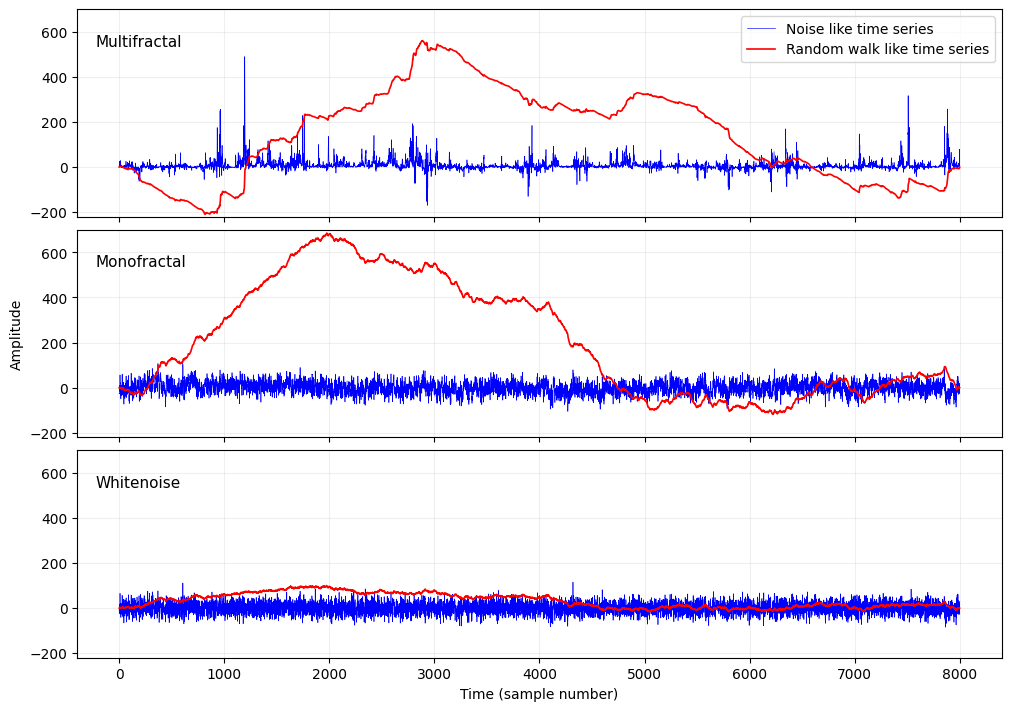

In [ ]:
rw = {name: np.cumsum(x - np.mean(x)) for name, x in signals.items()}

# Figure 1
noise_plot_gain = 25
panel_order = ("multifractal", "monofractal", "whitenoise")
fig, axes = plt.subplots(
    3, 1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
for ax, name in zip(axes, panel_order):
    ax.plot(
        signals[name] * noise_plot_gain,
        color="blue",
        lw=0.45,
        label=f"Noise like time series",
    )
    ax.plot(rw[name], color="red", lw=1.2, label="Random walk like time series")
    ax.text(
        0.02, 0.88, name.capitalize(), transform=ax.transAxes, va="top", fontsize=11
    )
    ax.set_ylim(-220, 700)
axes[0].legend(loc="upper right", frameon=True)
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()


whitenoise      RMS=1.000000, mean=-0.003542
monofractal     RMS=1.083341, mean=-0.039491
multifractal    RMS=1.000000, mean=0.314678


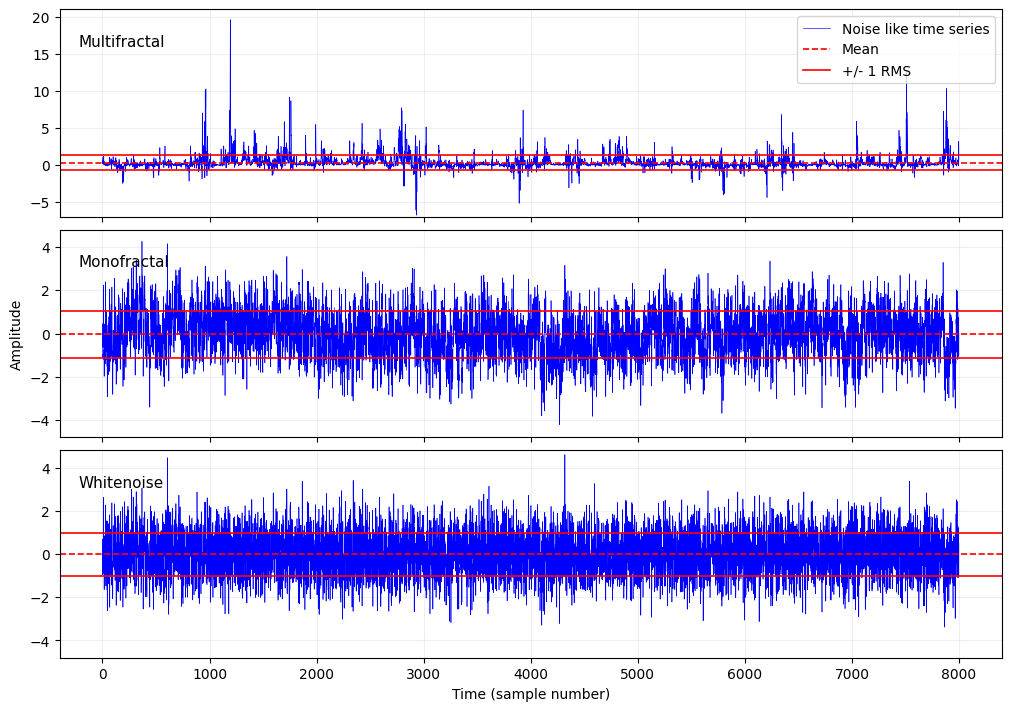

In [13]:
rms_values = {name: np.sqrt(np.mean(x**2)) for name, x in signals.items()}
for name, x in signals.items():
    print(f"{name:15s} RMS={rms_values[name]:.6f}, mean={x.mean():.6f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, layout="constrained")
for ax, name in zip(axes, ("multifractal", "monofractal", "whitenoise")):
    x = signals[name]
    mu = x.mean()
    rms = rms_values[name]
    ax.plot(x, color="blue", lw=0.45, label="Noise like time series")
    ax.axhline(mu, color="red", lw=1.2, ls="--", label="Mean")
    ax.axhline(mu + rms, color="red", lw=1.2, label="+/- 1 RMS")
    ax.axhline(mu - rms, color="red", lw=1.2)
    ax.text(
        0.02, 0.88, name.capitalize(), transform=ax.transAxes, va="top", fontsize=11
    )
    ax.set_ylim((-7, 21) if name == "multifractal" else (-4.8, 4.8))
axes[0].legend(loc="upper right")
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()


In [14]:
def local_rms(profile, scale, order=1, return_fits=False):
    n_segments = len(profile) // scale
    windows = profile[: n_segments * scale].reshape(n_segments, scale)
    t = np.linspace(-1.0, 1.0, scale)
    design = np.polynomial.polynomial.polyvander(t, order)
    basis, _ = np.linalg.qr(design)
    fits = (windows @ basis) @ basis.T
    rms = np.sqrt(np.mean((windows - fits) ** 2, axis=1))
    return (rms, fits) if return_fits else rms

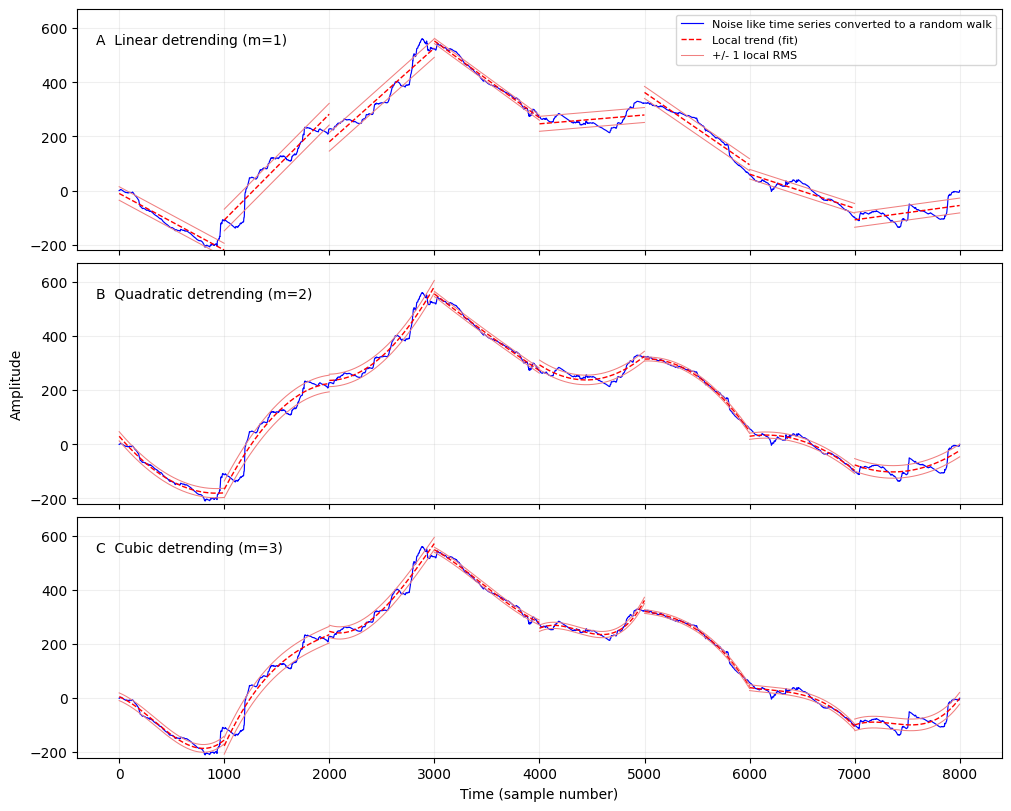

Local RMS (linear trend): [25.006 40.119 34.225  9.647 27.615 22.312 17.79  27.433]


In [17]:
scale_fig = 1000
X = rw["multifractal"]
local_rms_by_order = {
    m: local_rms(X, scale_fig, order=m, return_fits=True) for m in (1, 2, 3)
}
local, fits = local_rms_by_order[1]

fig, axes = plt.subplots(
    3, 1, figsize=(10, 8), sharex=True, sharey=True, layout="constrained"
)
for ax, (panel, order_name, m) in zip(
    axes, [("A", "Linear", 1), ("B", "Quadratic", 2), ("C", "Cubic", 3)]
):
    segment_rms, segment_fits = local_rms_by_order[m]
    ax.plot(
        X,
        color="blue",
        lw=0.85,
        label="Noise like time series converted to a random walk",
    )
    for v, trend in enumerate(segment_fits):
        t = np.arange(v * scale_fig, (v + 1) * scale_fig)
        ax.plot(
            t,
            trend,
            color="red",
            ls="--",
            lw=1,
            label="Local trend (fit)" if v == 0 else None,
        )
        for sign in (-1, 1):
            ax.plot(
                t,
                trend + sign * segment_rms[v],
                color="lightcoral",
                lw=0.75,
                label="+/- 1 local RMS" if v == 0 and sign == 1 else None,
            )
    ax.text(
        0.02,
        0.9,
        f"{panel}  {order_name} detrending (m={m})",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
    )
    ax.set_ylim(-220, 670)
axes[0].legend(loc="upper right", fontsize=8)
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()
print("Local RMS (linear trend):", np.round(local, 3))
